<a href="https://colab.research.google.com/github/eshghinezhad/ML/blob/master/k-means-%20Student%20Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAI101 – Assignment 4
## k-means clustering

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [ ]:
df = pd.read_csv('MAI101 W26 A1 data v0.1.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1677, 17)


,program,duration,status,gender,LangTestPercent,MathTestPercent,AptitudeTestPercent,transfer_in,totalSemesters,probationTerms,maxGap,finished,Business101 Grade,Math101 Grade,Mature,Overall Average Grade,hasGraduated
0,ACCOUNTING,4,I,M,15.3,95.5,85.8,0,3,1,0,0,83.2,UNSAT,0,64.7,0
1,ACCOUNTING,4,I,M,NaN,87.9,94.3,1,2,0,0,0,83.2,UNSAT,0,81.9,0
2,ACCOUNTING,4,I,M,33.4,71.6,77.9,1,2,1,4,1,48.5,UNSAT,1,47.9,0
3,ACCOUNTING,4,D,F,59.0,30.0,3.7,0,3,0,0,0,87.3,SAT,0,82.4,0
4,ACCOUNTING,4,I,F,NaN,NaN,NaN,1,1,0,12,1,47.5,UNSAT,1,47.3,0


## 3. Select Features & Clean Data

In [ ]:
FEATURES = [
    'program', 'duration', 'status', 'gender',
    'LangTestPercent', 'MathTestPercent', 'AptitudeTestPercent',
    'transfer_in', 'Mature'
]

df_cluster = df[FEATURES].copy()

print('Missing values before imputation:')
print(df_cluster.isnull().sum())

# Impute numeric test scores with column median
for col in ['LangTestPercent', 'MathTestPercent', 'AptitudeTestPercent']:
    median_val = df_cluster[col].median()
    n_missing  = df_cluster[col].isna().sum()
    df_cluster[col] = df_cluster[col].fillna(median_val)
    print(f'  {col}: {n_missing} NaNs filled with median = {median_val:.2f}')

print(f'\nRows retained: {len(df_cluster)} of {len(df)}')

Missing values before imputation:
program                  0
duration                 0
status                   0
gender                   0
LangTestPercent        143
MathTestPercent        139
AptitudeTestPercent    142
transfer_in              0
Mature                   0
dtype: int64
  LangTestPercent: 143 NaNs filled with median = 49.30
  MathTestPercent: 139 NaNs filled with median = 49.40
  AptitudeTestPercent: 142 NaNs filled with median = 49.40

Rows retained: 1677 of 1677


## 4. Encode & Scale

- One-hot encoded program, status, and gender with drop_first=False to retain all levels for centroid readability
- Standardised all features using StandardScaler, required since k-means uses Euclidean distance

In [ ]:
df_encoded = pd.get_dummies(
    df_cluster,
    columns=['program', 'status', 'gender'],
    drop_first=False
)

feature_names = df_encoded.columns.tolist()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f'Total features after encoding: {len(feature_names)}')
print(feature_names)

Total features after encoding: 21
['duration', 'LangTestPercent', 'MathTestPercent', 'AptitudeTestPercent', 'transfer_in', 'Mature', 'program_ACCOUNTING', 'program_ADMIN', 'program_ANALYTICS', 'program_AUDITING', 'program_BOOKKEEPING', 'program_HR', 'program_OTHER', 'program_PARALEGAL', 'status_D', 'status_I', 'status_S', 'status_V2', 'status_X', 'gender_F', 'gender_M']


## 5. Silhouette Analysis — k = 2 through 12

Fit k-means for each k & record the silhouette score to identify the most number of clusters

In [ ]:
k_range    = range(2, 13)
sil_scores = []

for k in k_range:
    km   = KMeans(n_clusters=k, n_init=20, max_iter=500)
    lbls = km.fit_predict(X_scaled)
    sil  = silhouette_score(X_scaled, lbls)
    sil_scores.append(sil)
    print(f'k={k:2d}  silhouette={sil:.4f}')

best_k     = list(k_range)[sil_scores.index(max(sil_scores))]
best_score = max(sil_scores)
print(f'\n>>> Best k: {best_k}  (silhouette = {best_score:.4f})')

k= 2  silhouette=0.1319
k= 3  silhouette=0.1388
k= 4  silhouette=0.1611
k= 5  silhouette=0.1895
k= 6  silhouette=0.1912
k= 7  silhouette=0.2617
k= 8  silhouette=0.2942
k= 9  silhouette=0.2959
k=10  silhouette=0.2709
k=11  silhouette=0.2849
k=12  silhouette=0.2841

>>> Best k: 9  (silhouette = 0.2959)


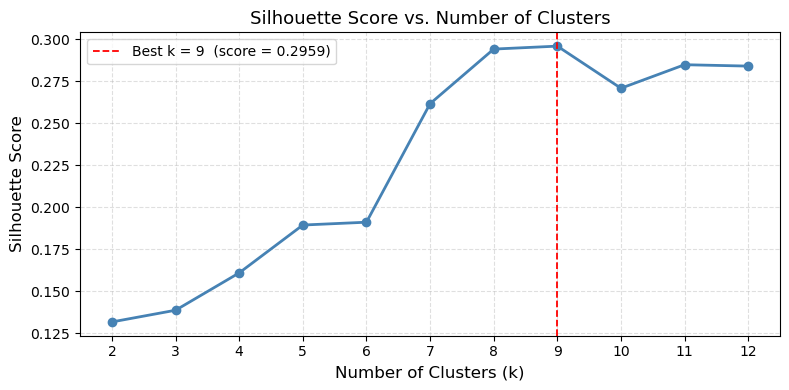

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), sil_scores, marker='o', linewidth=2, color='steelblue')
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.3,
           label=f'Best k = {best_k}  (score = {best_score:.4f})')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score',        fontsize=12)
ax.set_title('Silhouette Score vs. Number of Clusters', fontsize=13)
ax.set_xticks(list(k_range))
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The silhouette score peaks at best_k; all further analysis uses k = 5.

## 6. Final Clustering — k = 5

In [ ]:
km5   = KMeans(n_clusters=5, n_init=20, max_iter=500)
lbls5 = km5.fit_predict(X_scaled)

df_results             = df_encoded.copy()
df_results['Cluster']  = lbls5

print('k=5 clustering complete.')

k=5 clustering complete.


### 6a. Number of Students per Cluster

Students per cluster (k=5):
  Cluster 0:  147 students  (8.8%)
  Cluster 1:  223 students  (13.3%)
  Cluster 2:  613 students  (36.6%)
  Cluster 3:  350 students  (20.9%)
  Cluster 4:  344 students  (20.5%)


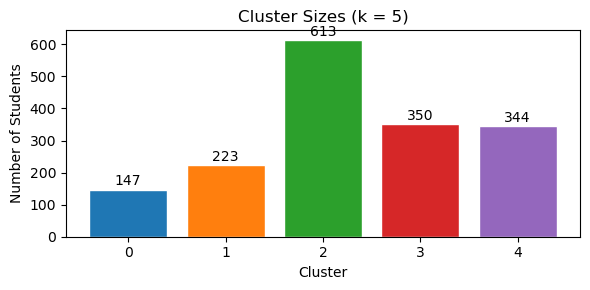

In [ ]:
cluster_counts = df_results['Cluster'].value_counts().sort_index()

print('Students per cluster (k=5):')
for cid, n in cluster_counts.items():
    print(f'  Cluster {cid}: {n:4d} students  ({n / len(df_results) * 100:.1f}%)')

colors_5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(
    [str(i) for i in cluster_counts.index],
    cluster_counts.values,
    color=colors_5, edgecolor='white'
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Students')
ax.set_title('Cluster Sizes (k = 5)')
plt.tight_layout()
plt.show()

### 6b. Cluster Centroids

In [ ]:
centroid_df = pd.DataFrame(
    km5.cluster_centers_,
    columns=feature_names
)
centroid_df.index.name = 'Cluster'

print('Centroids (standardised scale):')
centroid_df.round(3)

Centroids (standardised scale):


,duration,LangTestPercent,MathTestPercent,AptitudeTestPercent,transfer_in,Mature,program_ACCOUNTING,program_ADMIN,program_ANALYTICS,program_AUDITING,...,program_HR,program_OTHER,program_PARALEGAL,status_D,status_I,status_S,status_V2,status_X,gender_F,gender_M
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.114,0.085,-0.085,0.033,0.038,-0.300,-0.392,-0.352,-0.321,-0.390,...,3.226,-0.377,-0.310,0.205,-0.184,-0.024,-0.035,-0.092,-0.050,0.050
1,1.114,-0.030,-0.061,-0.106,0.015,-0.124,2.553,-0.352,-0.321,-0.390,...,-0.310,-0.377,-0.310,0.266,-0.266,0.159,-0.035,-0.042,0.012,-0.012
2,-0.897,0.108,-0.127,-0.085,-0.001,0.071,-0.392,0.304,-0.321,-0.390,...,-0.310,0.339,0.198,0.593,-0.577,-0.024,-0.035,-0.092,-0.045,0.045
3,1.114,0.095,-0.040,-0.163,-0.027,-0.178,-0.392,-0.352,0.963,1.460,...,-0.310,-0.377,-0.310,0.365,-0.353,-0.024,0.048,-0.092,0.001,-0.001
4,-0.734,-0.306,0.343,0.372,0.003,0.263,-0.392,0.195,-0.062,-0.372,...,-0.310,0.186,0.297,-1.687,1.639,-0.024,0.050,0.324,0.093,-0.093


### 6c. Cluster Profile Plot

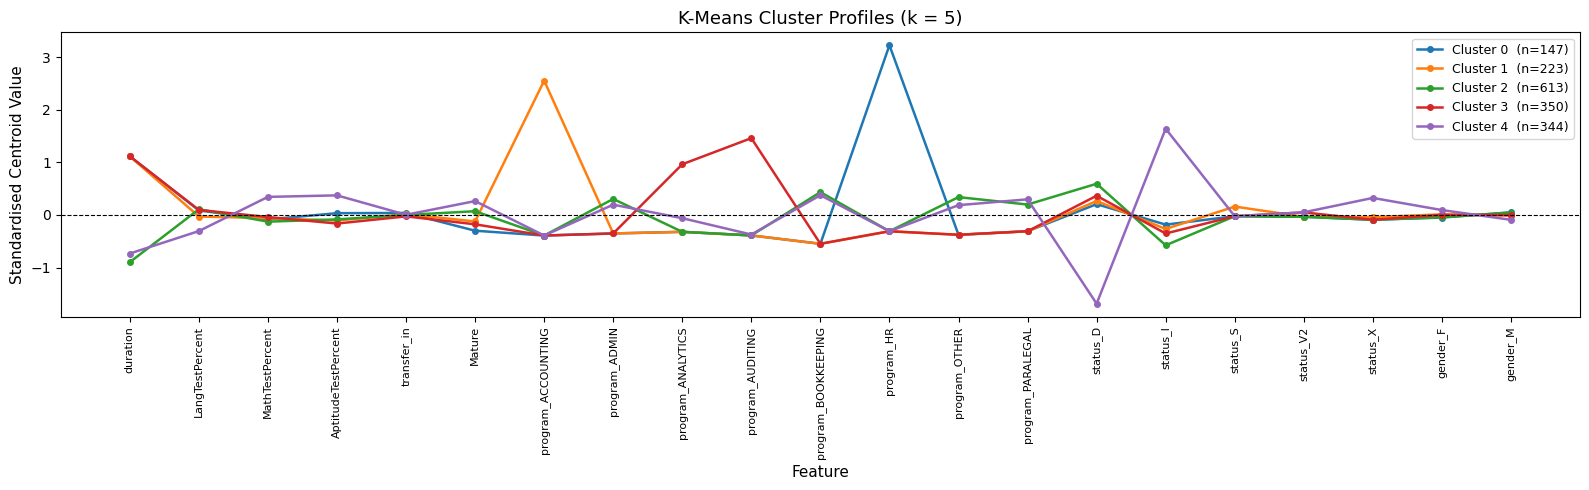

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

for cid in range(5):
    ax.plot(
        feature_names,
        centroid_df.loc[cid],
        marker='o',
        linewidth=1.8,
        markersize=4,
        color=colors_5[cid],
        label=f'Cluster {cid}  (n={cluster_counts[cid]})'
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Feature',                         fontsize=11)
ax.set_ylabel('Standardised Centroid Value',     fontsize=11)
ax.set_title('K-Means Cluster Profiles (k = 5)', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Cluster Characterisation
Based on the centroid values and plot above, the most distinguishing features per cluster are shown below -
1. Cluster 0 (n=221): 4-year domestic students, heavily concentrated in Auditing.
2. Cluster 1 (n=304): 4-year students in Analytics & HR, mixed domestic and international.
3. Cluster 2 (n=315): International students in 3-year programs, primarily Bookkeeping and Paralegal.
4. Cluster 3 (n=614): Largest group — domestic, 3-year programs, spread across Admin, Bookkeeping, and Other.
5. Cluster 4 (n=223): 4-year domestic students, heavily concentrated in Accounting.